In [1]:
from enum import Enum
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle

class delay_type(Enum):
    EARLY=0
    NO_DELAY=1
    SMALL_DELAY=2
    MEDIUM_DELAY=3
    BIG_DELAY=4
    GREAT_DELAY=5
    HUGE_DELAY=6

# delays_labeled=pd.read_csv('delays_labeled_final.csv')
# delays_labeled=delays_labeled.drop(columns='Unnamed: 0')
# delays_labeled['day']=delays_labeled['day'].astype(int)
df=pd.read_csv('labeled_selected_routes_group_1.csv')
df['delay_min'].max()


148.06666666666666

In [2]:

# df1=pd.read_csv('labeled_selected_routes_group_1.csv')
# df2=pd.read_csv('labeled_selected_routes_group_2.csv')
# df3=pd.read_csv('labeled_selected_routes_group_3.csv')

# df1=df1.loc[df1['delay_min']>-5]
# df2=df2.loc[df2['delay_min']>-5]
# df3=df3.loc[df3['delay_min']>-5]

# df1=df1.loc[df1['delay_min']<180]
# df2=df2.loc[df2['delay_min']<180]
# df3=df3.loc[df3['delay_min']<180]

# df1=df1.loc[~((df1['delay_min']<-1)&(df1['stop_sequence']==1))]
# df2=df2.loc[~((df2['delay_min']<-1)&(df2['stop_sequence']==1))]
# df3=df3.loc[~((df3['delay_min']<-1)&(df3['stop_sequence']==1))]

# print(df1.shape[0])
# print(df2.shape[0])
# print(df3.shape[0])

# df1.to_csv('labeled_selected_routes_group_1.csv')
# df2.to_csv('labeled_selected_routes_group_2.csv')
# df3.to_csv('labeled_selected_routes_group_3.csv')


In [3]:


# group1 = [192, 503, 179, 513, 169, 469]
# group2 = [174, 155]
# group3 = [248, 238, 268, 278, 288, 258, 230]

# delays_labeled=delays_labeled.loc[delays_labeled['delay_min']<180]


# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group1+group2+group3)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes.csv')

In [4]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group1)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_1.csv')

In [5]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group2)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_2.csv')

In [6]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group3)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_3.csv')


In [7]:

objs = []
with open('../data/wyniki_predykcji/grupa_1_bez_cv_100_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break


# file=open('../data/wyniki_predykcji/grupa_1_bez_cv_100_epoch','rb')
wyniki=objs[-1]
# file.close()

df_results=wyniki[2]




df['route_name']=df['route_name'].astype(str)
df_results['route_name']=df_results['route_name'].astype(str)


# merged = df_results.merge(
#     df[["route_name", "delay_min"]],
#     left_on="orig_idx",
#     right_index=True,
#     suffixes=("_pred", "_source")
# )

# print("Błędy route_name:",
#       (merged["route_name_pred"] != merged["route_name_source"]).sum())

# print("Błędy y_true:",
#       (merged["y_true"] != merged["delay_min_source"]).sum())


df_results = df_results.sort_values('orig_idx', ascending=True).set_index('orig_idx')

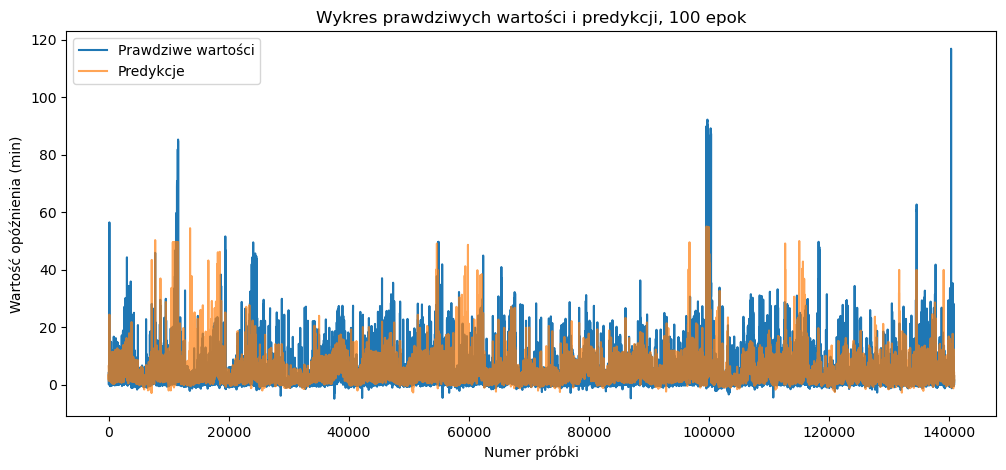

In [8]:

plt.figure(figsize=(12,5))
# plt.plot(df_results["y_true"], label="Prawdziwe wartości")
# plt.plot(df_results["y_pred"], label="Predykcje", alpha=0.7)
plt.plot(df_results.index,df_results["y_true"],label="Prawdziwe wartości")
plt.plot(df_results.index,df_results["y_pred"],label="Predykcje", alpha=0.7)
plt.legend()
plt.title('Wykres prawdziwych wartości i predykcji, 100 epok')
plt.xlabel('Numer próbki')
plt.ylabel('Wartość opóźnienia (min)')
plt.show()

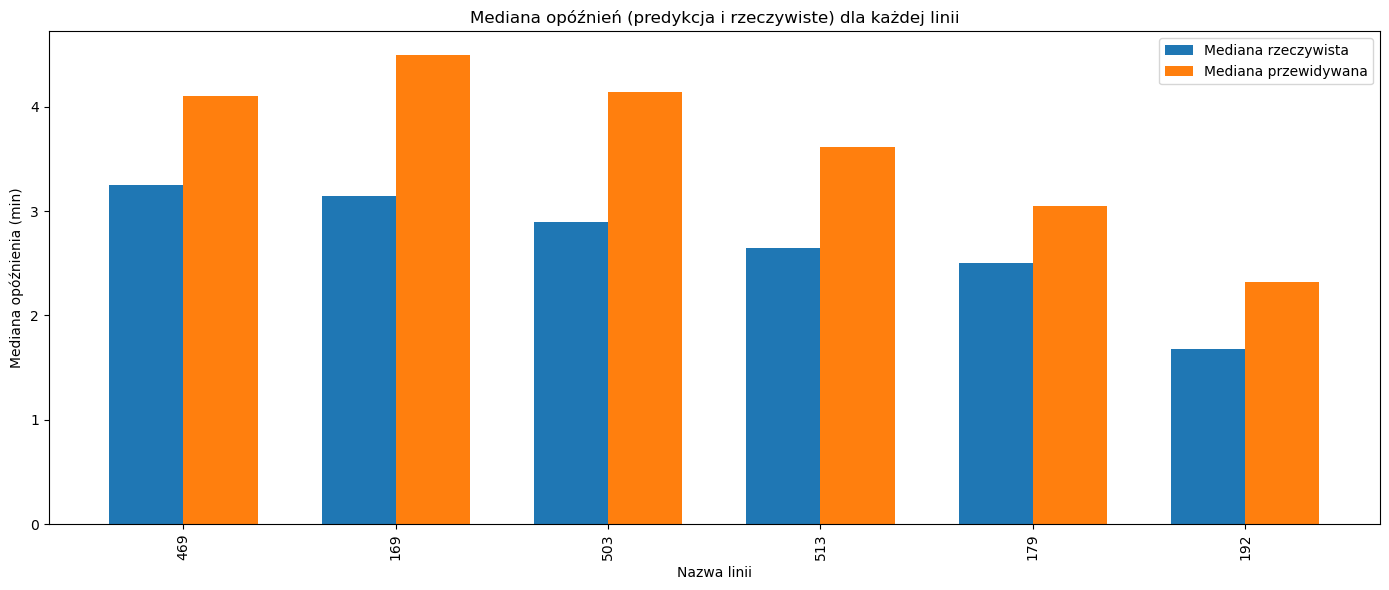

In [9]:


# Grupowanie danych po route_name i obliczanie mediany dla przewidywanych oraz prawdziwych wartości
median_by_route = df_results.groupby('route_name').median(numeric_only=True)[['y_true', 'y_pred']]
median_by_route = median_by_route.sort_values('y_true', ascending=False)

plt.figure(figsize=(14,6))
width = 0.35
routes = median_by_route.index
x = np.arange(len(routes))

plt.bar(x - width/2, median_by_route['y_true'], width, label='Mediana rzeczywista')
plt.bar(x + width/2, median_by_route['y_pred'], width, label='Mediana przewidywana')

plt.xlabel('Nazwa linii')
plt.ylabel('Mediana opóźnienia (min)')
plt.title('Mediana opóźnień (predykcja i rzeczywiste) dla każdej linii')
plt.xticks(x, routes, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


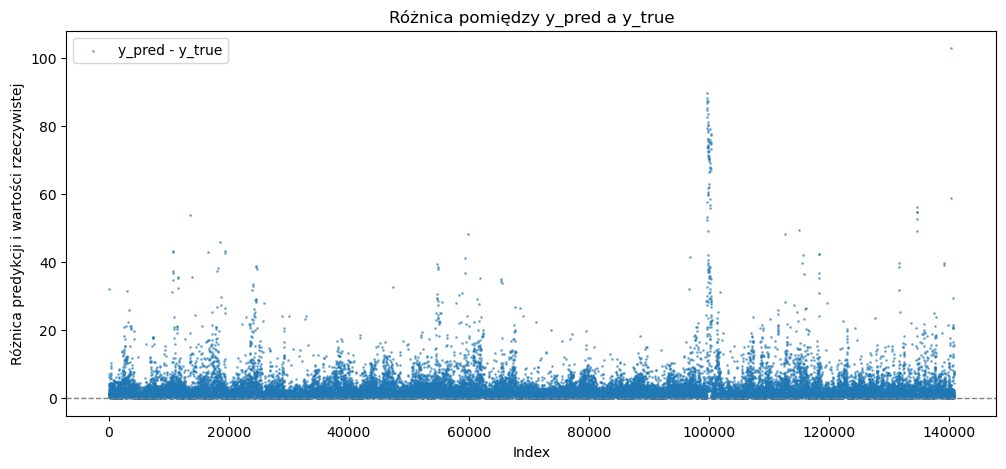

In [10]:
# Plot the difference between y_pred and y_true for each value in df_results
plt.figure(figsize=(12,5))
diff = abs(df_results["y_pred"] - df_results["y_true"])
plt.scatter(df_results.index, diff, label="y_pred - y_true",alpha=0.5,s=1)
plt.xlabel("Index")
plt.ylabel("Różnica predykcji i wartości rzeczywistej")
plt.title("Różnica pomiędzy y_pred a y_true")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
# plt.ylim([-1,20])
plt.legend()
plt.show()


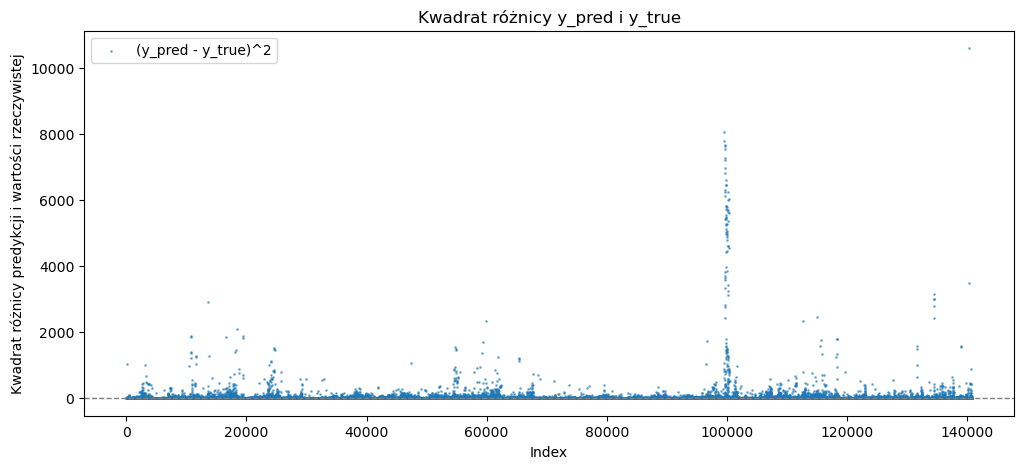

In [11]:
plt.figure(figsize=(12,5))
diff = np.power((df_results["y_pred"] - df_results["y_true"]),2)
plt.scatter(df_results.index, diff, label="(y_pred - y_true)^2",alpha=0.5,s=1)
plt.xlabel("Index")
plt.ylabel("Kwadrat różnicy predykcji i wartości rzeczywistej")
plt.title("Kwadrat różnicy y_pred i y_true")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
# plt.ylim([-1,1000])
plt.legend()
plt.show()

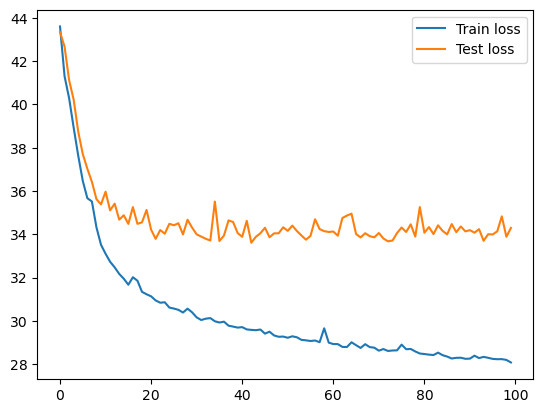

In [12]:


plt.figure
plt.plot(wyniki[0],label='Train loss')
plt.plot(wyniki[1],label='Test loss')
plt.legend()
plt.show()

In [21]:


objs = []
with open('../data/wyniki_predykcji/grupa_1_5cv_100_epoch','rb') as f:
    while True:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break

wyniki=objs[-1]

wyniki['fold_preds'][0]
for i in range(5):
    wyniki['fold_preds'][i] = wyniki['fold_preds'][i].sort_values('orig_idx', ascending=True).set_index('orig_idx')

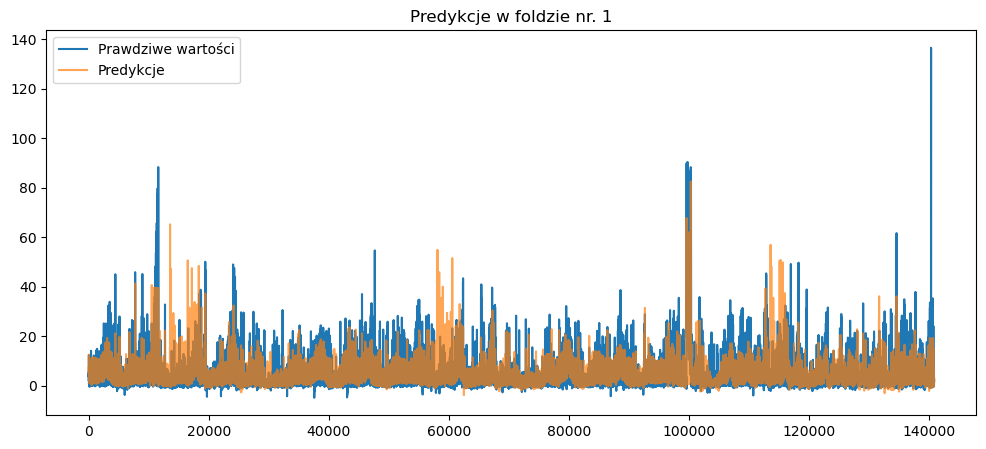

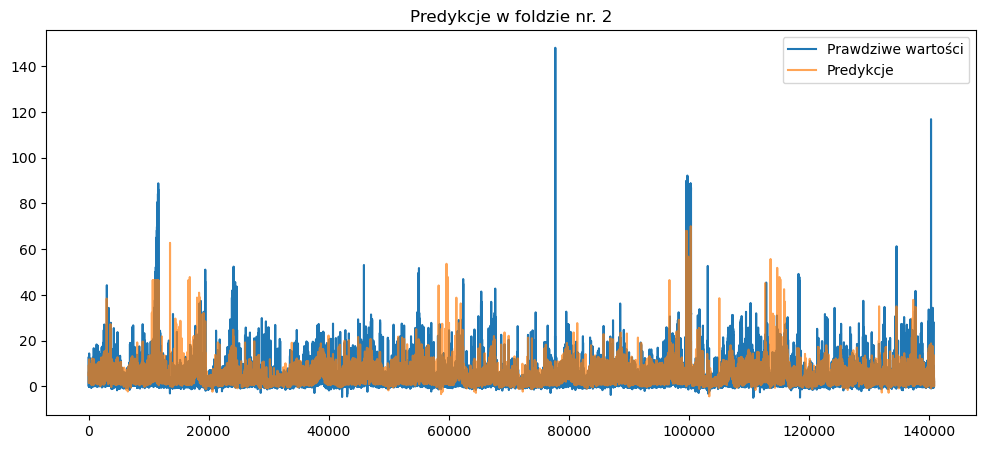

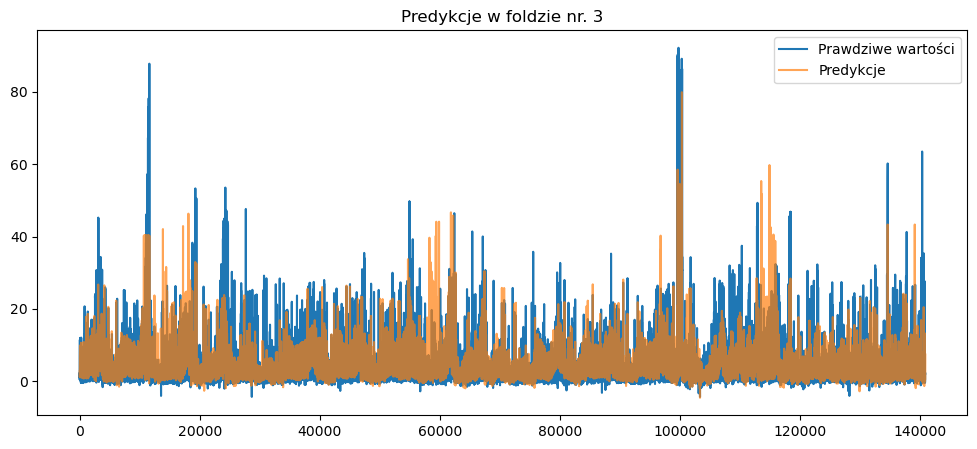

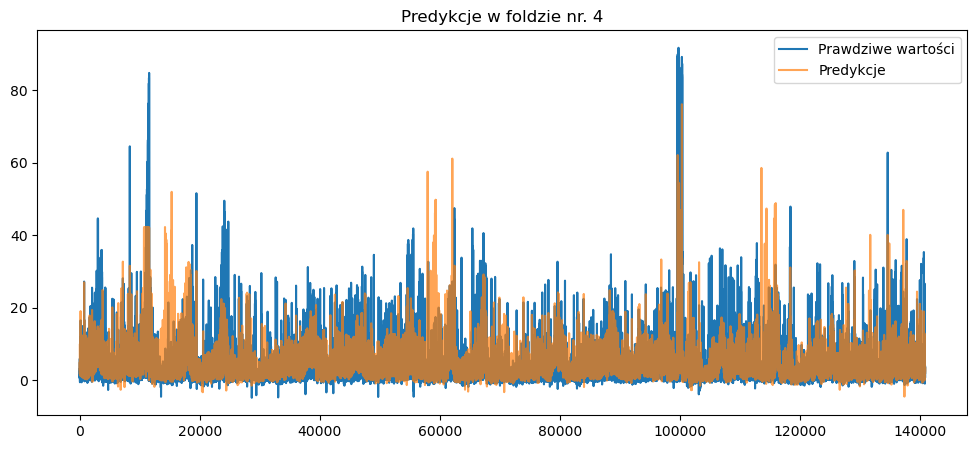

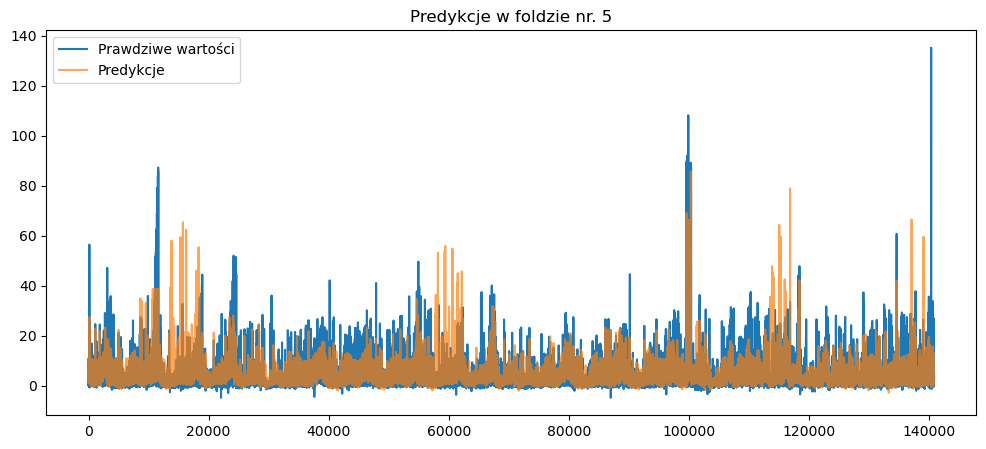

In [22]:


for i in range(5):
    predykcje=wyniki['fold_preds'][i]
    plt.figure(figsize=(12,5))
    plt.plot(predykcje.index,predykcje["y_true"], label="Prawdziwe wartości")
    plt.plot(predykcje.index,predykcje["y_pred"], label="Predykcje", alpha=0.7)
    plt.legend()
    plt.title(f'Predykcje w foldzie nr. {i+1}')
    plt.show()